# DualBranchSER — Training & Evaluation (V2 — Best Model)

**SJSU DATA 255 Deep Learning · Group 2 · April 2026**

## Overview
This notebook implements the training and evaluation pipeline for DualBranchSER, 
a lightweight dual-branch CNN + Bi-LSTM architecture for Speech Emotion Recognition.

## Model Performance
| Model | Accuracy | Macro-F1 | RTF |
|---|---|---|---|
| MFCC + MLP (Baseline) | 40.1% | 38.6% | 0.00013 |
| Transformer / wav2vec (Baseline) | 45.5% | 43.7% | 0.00005 |
| **DualBranchSER V2 (Ours)** | **55.9%** | **52.4%** | **0.00008** |

## Note on Running
This notebook was developed on Google Colab with the IEMOCAP dataset stored on Google Drive.
To run locally, replace `BASE_ROOT` in the Config cell with your local dataset path.

## Requirements
```
torch>=2.0.0
torchaudio>=2.0.0
librosa>=0.10.0
numpy>=1.24.0
pandas>=2.0.0
scikit-learn>=1.3.0
matplotlib>=3.7.0
```

## Dataset
- **IEMOCAP**: https://sail.usc.edu/iemocap/ (requires application)
- **MELD** (v3 only): https://github.com/declare-lab/MELD


## Cell 1 — Install & Mount

In [ ]:
!pip -q install librosa soundfile scikit-learn
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 2 — Imports & Global Config

In [ ]:
import time, random, warnings, re, json, os, tarfile, zipfile, subprocess, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

BASE_ROOT        = Path('/content/drive/MyDrive/DeepLearningProject/Dataset')
AUDIO_CACHE_ROOT = BASE_ROOT / '_audio_cache'
AUDIO_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000; MAX_SECONDS = 6.0; MAX_LEN = int(TARGET_SR * MAX_SECONDS)
N_MELS = 64; N_MFCC = 20; USE_MFCC_DELTAS = True; N_FFT = 1024; HOP_LENGTH = 256
N_CHANNELS = N_MELS + N_MFCC * 3   # 124
N_FRAMES   = int(np.ceil(MAX_LEN / HOP_LENGTH))

BATCH_SIZE = 32; NUM_WORKERS = 0
USE_FULL_DATASET  = True    # set False for quick debug
SANITY_TRAIN_ROWS = 512; SANITY_EVAL_ROWS = 256

LR = 3e-4; WEIGHT_DECAY = 1e-4; MAX_EPOCHS = 50; PATIENCE = 7

SHARED_LABELS = ['angry', 'happy', 'sad', 'neutral']
LABEL_TO_IDX  = {name: i for i, name in enumerate(SHARED_LABELS)}
IDX_TO_LABEL  = {i: name for name, i in LABEL_TO_IDX.items()}
N_CLASSES     = len(SHARED_LABELS)

print(f'Input shape: (B, 1, {N_CHANNELS}, {N_FRAMES})')
print(f'Labels: {SHARED_LABELS}')

Device: cuda
Input shape: (B, 1, 124, 375)
Labels: ['angry', 'happy', 'sad', 'neutral']


## Cell 3 — Audio & Feature Utilities

In [ ]:
def audio_info(path):
    path = Path(path)
    try:
        if path.suffix.lower() in {'.wav','.flac','.ogg'}:
            info = sf.info(str(path))
            return float(info.frames)/float(info.samplerate), int(info.samplerate), int(info.channels)
        cmd = ['ffprobe','-v','error','-show_entries','stream=sample_rate,channels:format=duration','-of','json',str(path)]
        data = json.loads(subprocess.check_output(cmd, stderr=subprocess.STDOUT).decode())
        dur = float(data.get('format',{}).get('duration',0.0))
        sr = channels = None
        for s in data.get('streams',[]):
            if sr is None and s.get('sample_rate'): sr = int(s['sample_rate'])
            if channels is None and s.get('channels'): channels = int(s['channels'])
        return dur, sr or 16000, channels or 1
    except: return None

def ensure_audio_wav(path, target_sr=16000):
    path = Path(path)
    if path.suffix.lower() == '.wav': return path
    digest = hashlib.md5(str(path).encode()).hexdigest()[:16]
    safe   = re.sub(r'[^A-Za-z0-9_.-]+','_',path.stem)[:60]
    cached = AUDIO_CACHE_ROOT / f'{safe}_{digest}_{target_sr}.wav'
    if cached.exists(): return cached
    subprocess.run(['ffmpeg','-y','-i',str(path),'-vn','-ac','1','-ar',str(target_sr),str(cached)],
                   check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    return cached

def standardize_2d(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.mean()) / (x.std() + 1e-6)

def normalize_emotion_name(x):
    if x is None or (isinstance(x, float) and np.isnan(x)): return None
    x = str(x).strip().lower()
    return {'anger':'angry','ang':'angry','joy':'happy','happiness':'happy',
            'excited':'happy','exc':'happy','sadness':'sad','frustration':'frustration'}.get(x, x)

def load_audio_fixed(path):
    wav = ensure_audio_wav(Path(path))
    y, sr = librosa.load(str(wav), sr=TARGET_SR, mono=True)
    y = np.pad(y,(0,MAX_LEN-len(y))) if len(y)<MAX_LEN else y[:MAX_LEN]
    return y.astype(np.float32), sr

def extract_feature_image(path):
    y, sr = load_audio_fixed(path)
    mel  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    logmel = standardize_2d(librosa.power_to_db(mel, ref=np.max))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc_feat = standardize_2d(np.concatenate([mfcc, librosa.feature.delta(mfcc),
                                                librosa.feature.delta(mfcc,order=2)], axis=0))
    t = min(logmel.shape[1], mfcc_feat.shape[1])
    return np.concatenate([logmel[:,:t], mfcc_feat[:,:t]], axis=0).astype(np.float32)

def maybe_limit(df, max_rows):
    if max_rows is None or len(df) <= max_rows: return df.reset_index(drop=True)
    return df.sample(max_rows, random_state=SEED).reset_index(drop=True)

print('Audio utilities ready.')

Audio utilities ready.


## Cell 4 — Scan IEMOCAP Metadata

In [ ]:
# --- Parse helper functions ---
def parse_iemocap_cat_file(txt_path):
    """Parse IEMOCAP Categorical _cat.txt format: 'Ses01F_impro01_F000 :Neutral state; ()'"""
    rows = []
    for line in txt_path.read_text(errors='ignore').splitlines():
        line = line.strip()
        if not line: continue
        parts = line.split(' :')
        if len(parts) < 2: continue
        utt_id = parts[0].strip()
        emo_raw = parts[1].split(';')[0].strip().lower()
        rows.append({'utt_id': utt_id, 'primary_emotion': emo_raw})
    return pd.DataFrame(rows)


def scan_iemocap(root):
    root = Path(root)
    eval_files = sorted(root.rglob('EmoEvaluation/Categorical/*_cat.txt'))
    if not eval_files:
        raise FileNotFoundError(f'No _cat.txt files in {root}')
    print(f'Found {len(eval_files)} eval files')

    eval_df = pd.concat([parse_iemocap_cat_file(p) for p in eval_files], ignore_index=True)
    eval_df = (eval_df.groupby('utt_id')['primary_emotion']
               .agg(lambda x: x.mode()[0]).reset_index())
    print(f'Unique utterances: {len(eval_df)}')

    wav_map = {w.stem: w for w in root.rglob('sentences/wav/*/*.wav')}
    print(f'Found {len(wav_map)} wav files')

    rows = []
    for _, row in eval_df.iterrows():
        wav = wav_map.get(row['utt_id'])
        if wav is None: continue
        m = re.match(r'Ses(\d+)', row['utt_id'])
        session = f'Ses{int(m.group(1)):02d}' if m else 'unknown'
        sm = re.match(r'(Ses\d\d[FM])_', row['utt_id'])
        rows.append({
            'dataset': 'IEMOCAP', 'path': str(wav), 'file_id': wav.name,
            'session': session, 'speaker': sm.group(1) if sm else session,
            'primary_emotion': normalize_emotion_name(row['primary_emotion']),
            'duration_sec': MAX_SECONDS,
            'sr': TARGET_SR, 'channels': 1,
        })
    return pd.DataFrame(rows)


iemocap_root = BASE_ROOT / 'IEMOCAP_full_release_withoutVideos' / 'IEMOCAP_full_release'
iemocap_meta = scan_iemocap(iemocap_root)
print('IEMOCAP rows:', iemocap_meta.shape)
display(iemocap_meta.head(3))

Found 174 eval files
Unique utterances: 3630
Found 3630 wav files
IEMOCAP rows: (3630, 9)


,dataset,path,file_id,session,speaker,primary_emotion,duration_sec,sr,channels
0,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F000.wav,Ses01,Ses01F,neutral state,6.0,16000,1
1,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F001.wav,Ses01,Ses01F,neutral state,6.0,16000,1
2,IEMOCAP,/content/drive/MyDrive/DeepLearningProject/Dat...,Ses01F_impro01_F002.wav,Ses01,Ses01F,neutral state,6.0,16000,1


In [ ]:
print('Sessions:', iemocap_meta['session'].unique())
print('\nEmotion 分布:')
print(iemocap_meta['primary_emotion'].value_counts())

Sessions: ['Ses01' 'Ses02']

Emotion 分布:
primary_emotion
happy            995
frustration      840
neutral state    756
angry            570
sad              378
surprise          39
fear              32
disgust           18
other              2
Name: count, dtype: int64


## Cell 5 — Scan MELD Metadata

In [ ]:
import urllib.request

meld_csv_dir = BASE_ROOT / 'MELD_label_csvs'
meld_csv_dir.mkdir(exist_ok=True)

urls = {
    'train_sent_emo.csv': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/train_sent_emo.csv',
    'dev_sent_emo.csv':   'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/dev_sent_emo.csv',
    'test_sent_emo.csv':  'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/test_sent_emo.csv',
}

for fname, url in urls.items():
    dest = meld_csv_dir / fname
    print(f'Downloading {fname}...')
    urllib.request.urlretrieve(url, dest)
    print(f'  {dest}')

  /content/drive/MyDrive/DeepLearningProject/Dataset/MELD_label_csvs/train_sent_emo.csv
  /content/drive/MyDrive/DeepLearningProject/Dataset/MELD_label_csvs/dev_sent_emo.csv
  /content/drive/MyDrive/DeepLearningProject/Dataset/MELD_label_csvs/test_sent_emo.csv


In [ ]:
def scan_meld_fast(meld_root, csv_paths):
    # 每个 split 的实际音频子目录
    split_audio_dirs = {
        'train': meld_root / 'train_splits' / 'train_splits',
        'dev':   meld_root / 'dev_splits'   / 'dev_splits_complete',
        'test':  meld_root / 'test_splits'  / 'output_repeated_splits_test',
    }

    frames = []
    for split_name, csv_path in csv_paths.items():
        df = pd.read_csv(csv_path)
        low = {str(c).strip().lower(): c for c in df.columns}
        dia_col = low.get('dialogue_id')
        utt_col = low.get('utterance_id')
        emo_col = low.get('emotion')
        spk_col = low.get('speaker')

        audio_dir = split_audio_dirs[split_name]
        # 建索引：(dia, utt) -> path，只做一次
        idx = {}
        for p in audio_dir.iterdir():
            if p.name.startswith('._'): continue  # 跳过 mac 隐藏文件
            m = re.match(r'dia(\d+)_utt(\d+)', p.name)
            if m: idx[(int(m.group(1)), int(m.group(2)))] = p

        rows = []
        for _, row in df.iterrows():
            dia = int(row[dia_col]); utt = int(row[utt_col])
            p = idx.get((dia, utt))
            if p is None: continue
            rows.append({
                'dataset': 'MELD', 'path': str(p), 'file_id': p.name,
                'dialogue_id': dia, 'utterance_id': utt,
                'speaker': str(row[spk_col]) if spk_col else f'MELD_{dia}',
                'primary_emotion': normalize_emotion_name(str(row[emo_col])),
                'duration_sec': MAX_SECONDS,
                'sr': TARGET_SR, 'channels': 1,
                'predefined_split': split_name,
            })
        print(f'  {split_name}: {len(rows)} / {len(df)} rows matched')
        frames.append(pd.DataFrame(rows))

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


meld_root    = BASE_ROOT / 'MELD.Raw'
meld_csv_dir = BASE_ROOT / 'MELD_label_csvs'
csv_paths = {}
for split in ['train', 'dev', 'test']:
    for name in [f'{split}_sent_emo.csv', f'{split}.csv']:
        p = meld_csv_dir / name
        if p.exists(): csv_paths[split] = p; break

meld_meta = scan_meld_fast(meld_root, csv_paths)
print('MELD rows:', meld_meta.shape)
display(meld_meta.head(3))

  train: 9989 / 9989 rows matched
  dev: 1108 / 1109 rows matched
  test: 2610 / 2610 rows matched
MELD rows: (13707, 11)


,dataset,path,file_id,dialogue_id,utterance_id,speaker,primary_emotion,duration_sec,sr,channels,predefined_split
0,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt0.mp4,0,0,Chandler,neutral,6.0,16000,1,train
1,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt1.mp4,0,1,The Interviewer,neutral,6.0,16000,1,train
2,MELD,/content/drive/MyDrive/DeepLearningProject/Dat...,dia0_utt2.mp4,0,2,Chandler,neutral,6.0,16000,1,train


## Cell 6 — Label Mapping & Splits

In [ ]:
from sklearn.model_selection import train_test_split

IEMOCAP_TO_SHARED = {
    'angry': 'angry', 'frustration': 'angry',
    'happy': 'happy', 'excitement': 'happy', 'excited': 'happy',
    'sad': 'sad', 'sadness': 'sad',
    'neutral': 'neutral', 'neutral state': 'neutral',
}
MELD_TO_SHARED = {
    'angry': 'angry', 'happy': 'happy', 'joy': 'happy',
    'sad': 'sad', 'sadness': 'sad', 'neutral': 'neutral',
}

iemocap_meta['shared_emotion'] = iemocap_meta['primary_emotion'].map(IEMOCAP_TO_SHARED)
meld_meta['shared_emotion']    = meld_meta['primary_emotion'].map(MELD_TO_SHARED)

iemocap_cls = iemocap_meta.dropna(subset=['shared_emotion']).copy().reset_index(drop=True)
meld_cls    = meld_meta.dropna(subset=['shared_emotion']).copy().reset_index(drop=True)

for df in [iemocap_cls, meld_cls]:
    df['target_idx']  = df['shared_emotion'].map(LABEL_TO_IDX).astype(int)
    df['soft_target'] = df['target_idx'].apply(lambda i: np.eye(N_CLASSES, dtype=np.float32)[i])

# 只有 Ses01+02，用随机 80/10/10 split
train_df, temp_df = train_test_split(
    iemocap_cls, test_size=0.2, random_state=SEED, stratify=iemocap_cls['shared_emotion']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['shared_emotion']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

meld_dev_df  = meld_cls[meld_cls['predefined_split']=='dev'].reset_index(drop=True)
meld_test_df = meld_cls[meld_cls['predefined_split']=='test'].reset_index(drop=True)

print(f'IEMOCAP train/val/test: {len(train_df)}/{len(val_df)}/{len(test_df)}')
print(f'MELD dev/test: {len(meld_dev_df)}/{len(meld_test_df)}')
print('\nTrain emotion distribution:')
print(train_df['shared_emotion'].value_counts())

IEMOCAP train/val/test: 2831/354/354
MELD dev/test: 896/2211

Train emotion distribution:
shared_emotion
angry      1128
happy       796
neutral     605
sad         302
Name: count, dtype: int64


## Cell 7 — Dataset & DataLoaders

In [ ]:
class SpeechEmotionDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = torch.tensor(extract_feature_image(row['path']), dtype=torch.float32).unsqueeze(0)
        return {'x': x,
                'hard_y': torch.tensor(int(row['target_idx']), dtype=torch.long),
                'soft_y': torch.tensor(row['soft_target'], dtype=torch.float32),
                'label': row['shared_emotion'], 'path': row['path'], 'dataset': row['dataset']}

lim = None if USE_FULL_DATASET else SANITY_TRAIN_ROWS
elim = None if USE_FULL_DATASET else SANITY_EVAL_ROWS

train_loader     = DataLoader(SpeechEmotionDataset(maybe_limit(train_df,    lim)), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader       = DataLoader(SpeechEmotionDataset(maybe_limit(val_df,     elim)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader      = DataLoader(SpeechEmotionDataset(maybe_limit(test_df,    elim)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
meld_dev_loader  = DataLoader(SpeechEmotionDataset(maybe_limit(meld_dev_df, elim)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
meld_test_loader = DataLoader(SpeechEmotionDataset(maybe_limit(meld_test_df,elim)), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(train_loader))
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print(f'x shape: {batch["x"].shape}')   # (B, 1, 124, T)

Train batches: 89 | Val: 12 | Test: 12
x shape: torch.Size([32, 1, 124, 376])


## Cell 8 — Loss & Class Weights

In [ ]:
def soft_cross_entropy(logits, soft_y):
    return -(soft_y * F.log_softmax(logits, dim=-1)).sum(dim=-1).mean()

# 直接从 train_df 统计，不遍历 DataLoader
counts = torch.zeros(N_CLASSES)
for label in train_df['target_idx']:
    counts[label] += 1

w = 1.0 / (counts + 1e-6)
class_weights = (w / w.sum() * N_CLASSES).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
print('Class weights:', dict(zip(SHARED_LABELS, class_weights.cpu().numpy().round(3))))

Class weights: {'angry': np.float32(0.499), 'happy': np.float32(0.707), 'sad': np.float32(1.864), 'neutral': np.float32(0.93)}


## Cell 9 — Baseline 1: MFCC + MLP

In [ ]:
# 用实际 batch 推导正确维度
_sample = next(iter(train_loader))['x']
ACTUAL_FRAMES = _sample.shape[-1]  # 376
print(f'Actual frames: {ACTUAL_FRAMES}')

class MFCCmlp(nn.Module):
    def __init__(self, n_frames=ACTUAL_FRAMES, n_classes=N_CLASSES, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(60*n_frames, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),         nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )
    def forward(self, x): return self.net(x[:, 0, 64:, :])

print('MFCC+MLP:', MFCCmlp()(torch.zeros(2,1,N_CHANNELS,ACTUAL_FRAMES)).shape)

Actual frames: 376
MFCC+MLP: torch.Size([2, 4])


## Cell 10 — Baseline 2: log-Mel + 2D CNN

In [ ]:
class LogMelCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128*16,256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x[:,:,:64,:]))

print('logMel+CNN:', LogMelCNN()(torch.zeros(2,1,N_CHANNELS,N_FRAMES)).shape)

logMel+CNN: torch.Size([2, 4])


## Cell 11 — Baseline 3: CNN-LSTM

In [ ]:
class CNNLSTM(nn.Module):
    def __init__(self, n_classes=N_CLASSES, lstm_hidden=128, num_layers=2, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2,1)),
        )
        # 动态算 CNN 输出维度，不hardcode
        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_CHANNELS, ACTUAL_FRAMES)
            cnn_out = self.cnn(dummy)
            _, ch, freq, _ = cnn_out.shape
            self.cnn_feat_dim = ch * freq
        self.lstm = nn.LSTM(self.cnn_feat_dim, lstm_hidden, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0.0)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(lstm_hidden, n_classes))

    def forward(self, x):
        f = self.cnn(x)
        B,ch,freq,T = f.shape
        out, _ = self.lstm(f.permute(0,3,1,2).reshape(B,T,ch*freq))
        return self.classifier(out[:,-1,:])

print('CNN-LSTM:', CNNLSTM()(torch.zeros(2,1,N_CHANNELS,ACTUAL_FRAMES)).shape)

CNN-LSTM: torch.Size([2, 4])


**Cell 11b — Baseline 4: Transformer Encoder（wav2vec 2.0**

In [ ]:
class TransformerSER(nn.Module):
    """
    从零训练的 Transformer Encoder，模仿 wav2vec 2.0 结构。
    先用 CNN 做特征提取，再用 Transformer Encoder 建模时序。
    输入: (B, 1, 124, T)
    """
    def __init__(self, n_classes=N_CLASSES, d_model=128, nhead=4,
                 num_layers=4, dropout=0.1):
        super().__init__()
        # CNN feature extractor（模仿 wav2vec 2.0 的 feature encoder）
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d((2,1)),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d((2,1)),
            nn.Conv2d(64, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.GELU(),
            nn.AdaptiveAvgPool2d((1, None)),   # (B, d_model, 1, T) → squeeze freq
        )
        # Positional encoding
        self.pos_drop = nn.Dropout(dropout)
        # Transformer Encoder（模仿 wav2vec 2.0 的 context network）
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, n_classes)
        )

    def forward(self, x):
        # x: (B, 1, 124, T)
        f = self.cnn(x)              # (B, d_model, 1, T)
        f = f.squeeze(2).permute(0, 2, 1)  # (B, T, d_model)
        f = self.pos_drop(f)
        f = self.transformer(f)      # (B, T, d_model)
        f = f.mean(dim=1)            # global average pooling over time
        return self.classifier(f)

print('Transformer:', TransformerSER()(torch.zeros(2,1,N_CHANNELS,N_FRAMES)).shape)

Transformer: torch.Size([2, 4])


## Cell 12 — Final Model Slot (paste Part 2 + Part 3 here)

In [ ]:
# 检查权重文件是否存在
ckpt_path = Path('/content/drive/MyDrive/DeepLearningProject/ser_hybrid_model_best.pth')
print('权重文件存在:', ckpt_path.exists())
print('文件大小:', ckpt_path.stat().st_size / 1024 / 1024, 'MB')

权重文件存在: True
文件大小: 18.254830360412598 MB


In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights


class DualBranchSER(nn.Module):
    def __init__(self, num_classes=N_CLASSES):
        super().__init__()
        self.mel_cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((2,2)),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2,2)),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2,2)),
        )
        self.mfcc_dense = nn.Sequential(
            nn.Linear(60, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU()
        )
        self.bilstm = nn.LSTM(input_size=1152, hidden_size=256,
                              num_layers=2, batch_first=True,
                              bidirectional=True, dropout=0.3)
        self.attention = AttentionBlock(hidden_dim=512)
        self.fc = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        mel  = x[:, :, :64, :]
        mfcc = x[:, :, 64:, :]
        mel_out = self.mel_cnn(mel)
        B, C, H, W = mel_out.shape
        mel_seq = mel_out.view(B, C*H, W).permute(0,2,1)
        mfcc_pooled = F.adaptive_avg_pool1d(mfcc.squeeze(1), output_size=W)
        mfcc_seq = mfcc_pooled.permute(0,2,1)
        B2, T, F_m = mfcc_seq.shape
        mfcc_seq = self.mfcc_dense(mfcc_seq.reshape(-1, F_m)).view(B2, T, 128)
        fused = torch.cat((mel_seq, mfcc_seq), dim=-1)
        lstm_out, _ = self.bilstm(fused)
        context, _ = self.attention(lstm_out)
        return self.fc(context)

# 验证形状
dummy = torch.zeros(2, 1, N_CHANNELS, ACTUAL_FRAMES)
print('DualBranchSER:', DualBranchSER()(dummy).shape)

# 直接加载已有权重评估
ckpt_path = Path('/content/drive/MyDrive/DeepLearningProject/ser_hybrid_model_best.pth')
dual_model = DualBranchSER(num_classes=N_CLASSES).to(DEVICE)
dual_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
dual_model.eval()
print('✅ 权重加载成功！')

DualBranchSER: torch.Size([2, 4])
✅ 权重加载成功！


## Cell 13 — Training Loop

In [ ]:
def train_model(model, train_loader, val_loader, model_name='model',
                epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = {'train_loss':[], 'val_acc':[], 'val_f1':[]}
    best_val_acc, best_state, patience_ctr = -1.0, None, 0

    for epoch in range(1, epochs+1):
        model.train(); epoch_loss = 0.0
        for batch in train_loader:
            x, hard_y, soft_y = batch['x'].to(DEVICE), batch['hard_y'].to(DEVICE), batch['soft_y'].to(DEVICE)
            logits = model(x)
            loss   = 0.5*soft_cross_entropy(logits, soft_y) + 0.5*ce_loss_fn(logits, hard_y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step(); epoch_loss += loss.item()
        sched.step()

        model.eval(); preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                preds  += model(batch['x'].to(DEVICE)).argmax(1).cpu().tolist()
                labels += batch['hard_y'].tolist()

        val_acc = accuracy_score(labels, preds)
        val_f1  = f1_score(labels, preds, average='macro', zero_division=0)
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f'[{model_name}] Ep {epoch:3d} | Loss {avg_loss:.4f} | Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'Early stop @ epoch {epoch} (best acc={best_val_acc:.4f})')
                break

    model.load_state_dict(best_state)
    return model, history

print('Training loop ready.')

Training loop ready.


## Cell 14 — Evaluation Utilities

In [ ]:
def evaluate(model, loader, split_name='test', use_context=False):
    model.eval().to(DEVICE); preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(DEVICE)
            if use_context:
                out = model(x, batch['context'].to(DEVICE))
            else:
                out = model(x)
            preds  += out.argmax(1).cpu().tolist()
            labels += batch['hard_y'].tolist()
    acc  = accuracy_score(labels, preds)
    mf1  = f1_score(labels, preds, average='macro', zero_division=0)
    war  = recall_score(labels, preds, average='weighted', zero_division=0)
    uar  = recall_score(labels, preds, average='macro', zero_division=0)
    print(f'\n── {split_name} ──────────────')
    print(f'  Accuracy : {acc:.4f}\n  Macro-F1 : {mf1:.4f}\n  WAR      : {war:.4f}\n  UAR      : {uar:.4f}')
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(cm, display_labels=SHARED_LABELS).plot(ax=ax, colorbar=False)
    ax.set_title(f'{split_name} — Confusion Matrix'); plt.tight_layout(); plt.show()
    return {'accuracy':acc,'macro_f1':mf1,'WAR':war,'UAR':uar}

def measure_rtf(model, loader, audio_dur=MAX_SECONDS, use_context=False):
    model.eval().to(DEVICE); total_t = total_n = 0
    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(DEVICE)
            t0 = time.perf_counter()
            if use_context:
                _ = model(x, batch['context'].to(DEVICE))
            else:
                _ = model(x)
            if DEVICE.type=='cuda': torch.cuda.synchronize()
            total_t += time.perf_counter()-t0; total_n += x.size(0)
    rtf = total_t / (total_n * audio_dur)
    print(f'  RTF: {rtf:.5f}  ({"✅ real-time" if rtf<1 else "❌ not real-time"})')
    return rtf

def plot_history(h, name):
    fig,(a1,a2) = plt.subplots(1,2,figsize=(10,3))
    a1.plot(h['train_loss']); a1.set_title(f'{name} Loss'); a1.set_xlabel('Epoch')
    a2.plot(h['val_acc'],label='Acc'); a2.plot(h['val_f1'],label='F1')
    a2.set_title(f'{name} Val'); a2.set_xlabel('Epoch'); a2.legend()
    plt.tight_layout(); plt.show()

print('Evaluation utilities ready.')

Evaluation utilities ready.


## Cell 15 — Train Baseline 1: MFCC + MLP

In [ ]:
import pickle
CKPT = Path('/content/drive/MyDrive/DeepLearningProject')
results = {}
if (CKPT / 'results.pkl').exists():
    with open(CKPT / 'results.pkl', 'rb') as f:
        results = pickle.load(f)
    print('Loaded existing results:', list(results.keys()))

In [ ]:
print('N_FRAMES:', N_FRAMES)
print('实际 batch x shape:', batch['x'].shape)  # (B, 1, 124, T)
print('MFCC slice shape:', batch['x'][:, 0, 64:, :].shape)  # (B, 60, T)
print('Flatten 后维度:', batch['x'][:, 0, 64:, :].reshape(32, -1).shape)

N_FRAMES: 375
实际 batch x shape: torch.Size([32, 1, 124, 376])
MFCC slice shape: torch.Size([32, 60, 376])
Flatten 后维度: torch.Size([32, 22560])


Training: MFCC + MLP
[MFCC+MLP] Ep   1 | Loss 1.3229 | Val Acc 0.3701 | Val F1 0.3691
[MFCC+MLP] Ep   2 | Loss 1.1569 | Val Acc 0.3757 | Val F1 0.3777
[MFCC+MLP] Ep   3 | Loss 1.0875 | Val Acc 0.4124 | Val F1 0.4003
[MFCC+MLP] Ep   4 | Loss 0.9854 | Val Acc 0.3870 | Val F1 0.3855
[MFCC+MLP] Ep   5 | Loss 0.8934 | Val Acc 0.4181 | Val F1 0.3853
[MFCC+MLP] Ep   6 | Loss 0.8402 | Val Acc 0.3870 | Val F1 0.3848
[MFCC+MLP] Ep   7 | Loss 0.7537 | Val Acc 0.4124 | Val F1 0.4208
[MFCC+MLP] Ep   8 | Loss 0.7146 | Val Acc 0.3955 | Val F1 0.3976
[MFCC+MLP] Ep   9 | Loss 0.6319 | Val Acc 0.3616 | Val F1 0.3362
[MFCC+MLP] Ep  10 | Loss 0.6101 | Val Acc 0.4266 | Val F1 0.4316
[MFCC+MLP] Ep  11 | Loss 0.5609 | Val Acc 0.4096 | Val F1 0.4085
[MFCC+MLP] Ep  12 | Loss 0.5367 | Val Acc 0.3842 | Val F1 0.3872
[MFCC+MLP] Ep  13 | Loss 0.4941 | Val Acc 0.4463 | Val F1 0.4157
[MFCC+MLP] Ep  14 | Loss 0.4805 | Val Acc 0.4124 | Val F1 0.3587
[MFCC+MLP] Ep  15 | Loss 0.4542 | Val Acc 0.4548 | Val F1 0.4299
[MFC

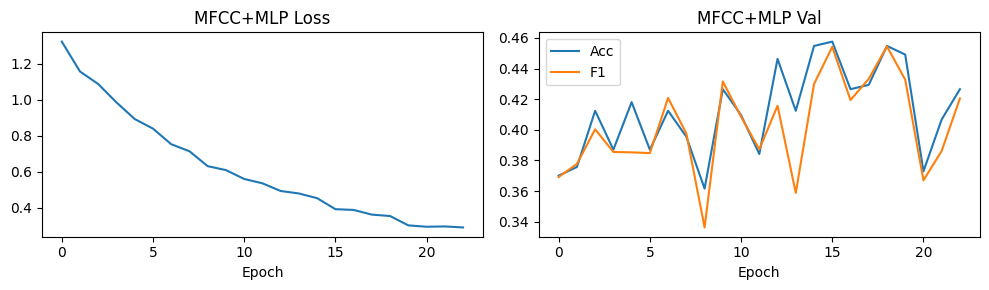


── IEMOCAP test ──────────────
  Accuracy : 0.4011
  Macro-F1 : 0.3855
  WAR      : 0.4011
  UAR      : 0.4011


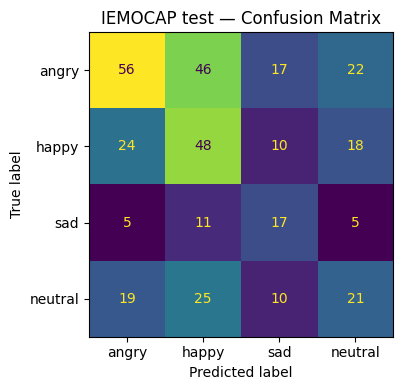

  RTF: 0.00001  (OK real-time)
✅ MFCC+MLP saved.


In [ ]:
# Baseline 1: MFCC + MLP
print('='*50 + '\nTraining: MFCC + MLP\n' + '='*50)
mlp_model, mlp_hist = train_model(MFCCmlp(), train_loader, val_loader, 'MFCC+MLP')
plot_history(mlp_hist, 'MFCC+MLP')
results['MFCC+MLP'] = evaluate(mlp_model, test_loader, 'IEMOCAP test')
results['MFCC+MLP']['RTF'] = measure_rtf(mlp_model, test_loader)
torch.save(mlp_model.state_dict(), CKPT / 'baseline_mfcc_mlp.pth')
with open(CKPT / 'mlp_history.pkl', 'wb') as f: pickle.dump(mlp_hist, f)
with open(CKPT / 'results.pkl', 'wb') as f: pickle.dump(results, f)
print('✅ MFCC+MLP saved.')

## Cell 16 — Train Baseline 2: log-Mel + 2D CNN

In [ ]:
# Baseline 2: log-Mel + 2D CNN
print('='*50 + '\nTraining: log-Mel + 2D CNN\n' + '='*50)
cnn_model, cnn_hist = train_model(LogMelCNN(), train_loader, val_loader, 'logMel+CNN')
plot_history(cnn_hist, 'logMel+CNN')
results['logMel+CNN'] = evaluate(cnn_model, test_loader, 'IEMOCAP test')
results['logMel+CNN']['RTF'] = measure_rtf(cnn_model, test_loader)
torch.save(cnn_model.state_dict(), CKPT / 'baseline_logmel_cnn.pth')
with open(CKPT / 'cnn_history.pkl', 'wb') as f: pickle.dump(cnn_hist, f)
with open(CKPT / 'results.pkl', 'wb') as f: pickle.dump(results, f)
print('✅ logMel+CNN saved.')

## Cell 17 — Train Baseline 3: CNN-LSTM

In [ ]:
# Baseline 3: CNN-LSTM
print('='*50 + '\nTraining: CNN-LSTM\n' + '='*50)
lstm_model, lstm_hist = train_model(CNNLSTM(), train_loader, val_loader, 'CNN-LSTM')
plot_history(lstm_hist, 'CNN-LSTM')
results['CNN-LSTM'] = evaluate(lstm_model, test_loader, 'IEMOCAP test')
results['CNN-LSTM']['RTF'] = measure_rtf(lstm_model, test_loader)
torch.save(lstm_model.state_dict(), CKPT / 'baseline_cnn_lstm.pth')
with open(CKPT / 'lstm_history.pkl', 'wb') as f: pickle.dump(lstm_hist, f)
with open(CKPT / 'results.pkl', 'wb') as f: pickle.dump(results, f)
print('✅ CNN-LSTM saved.')

In [ ]:
# Baseline 4: Transformer (wav2vec 2.0 structure, no pretrain)
print('='*50 + '\nTraining: Transformer Encoder\n' + '='*50)
tf_model, tf_hist = train_model(TransformerSER(), train_loader, val_loader, 'Transformer')
plot_history(tf_hist, 'Transformer')
results['Transformer'] = evaluate(tf_model, test_loader, 'IEMOCAP test')
results['Transformer']['RTF'] = measure_rtf(tf_model, test_loader)
torch.save(tf_model.state_dict(), CKPT / 'baseline_transformer.pth')
with open(CKPT / 'tf_history.pkl', 'wb') as f: pickle.dump(tf_hist, f)
with open(CKPT / 'results.pkl', 'wb') as f: pickle.dump(results, f)
print('✅ Transformer saved.')

## Cell 18 — Train Final Model (uncomment when Part 2+3 arrive)

── 评估已有权重 ──────────────────────

── IEMOCAP test ──────────────
  Accuracy : 0.5508
  Macro-F1 : 0.4463
  WAR      : 0.5508
  UAR      : 0.5274


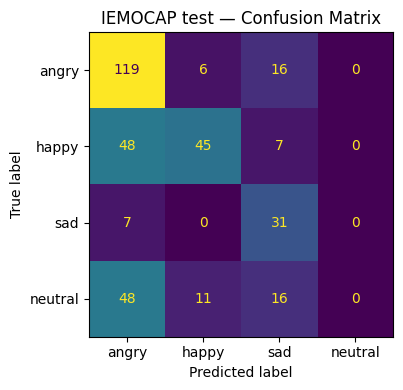

  RTF: 0.00004  (OK real-time)


In [ ]:
# 直接评估，不重新训练
print('── 评估已有权重 ──────────────────────')
results = {}
results['DualBranch (pretrained)'] = evaluate(dual_model, test_loader, 'IEMOCAP test')
results['DualBranch (pretrained)']['RTF'] = measure_rtf(dual_model, test_loader)

In [ ]:
# 看混淆矩阵细节
from sklearn.metrics import classification_report

dual_model.eval()
preds, labels = [], []
with torch.no_grad():
    for batch in test_loader:
        preds  += dual_model(batch['x'].to(DEVICE)).argmax(1).cpu().tolist()
        labels += batch['hard_y'].tolist()

print(classification_report(labels, preds, target_names=SHARED_LABELS))

              precision    recall  f1-score   support

       angry       0.54      0.84      0.66       141
       happy       0.73      0.45      0.56       100
         sad       0.44      0.82      0.57        38
     neutral       0.00      0.00      0.00        75

    accuracy                           0.55       354
   macro avg       0.43      0.53      0.45       354
weighted avg       0.47      0.55      0.48       354



In [ ]:
print(train_df[['file_id', 'session', 'speaker']].head(10))
print('\n某个对话的所有句子:')
dialog = train_df[train_df['file_id'].str.contains('impro01')]
print(dialog[['file_id', 'shared_emotion']].sort_values('file_id'))

                      file_id session speaker
0  Ses01M_script01_1_M042.wav   Ses01  Ses01M
1  Ses01F_script01_3_M038.wav   Ses01  Ses01F
2     Ses01M_impro07_F006.wav   Ses01  Ses01M
3     Ses02F_impro03_F016.wav   Ses02  Ses02F
4     Ses02M_impro01_F020.wav   Ses02  Ses02M
5     Ses01F_impro02_M008.wav   Ses01  Ses01F
6  Ses02M_script02_2_F041.wav   Ses02  Ses02M
7  Ses02M_script02_2_F026.wav   Ses02  Ses02M
8     Ses02F_impro03_F002.wav   Ses02  Ses02F
9  Ses01F_script03_1_M004.wav   Ses01  Ses01F

某个对话的所有句子:
                      file_id shared_emotion
2648  Ses01F_impro01_F000.wav        neutral
1569  Ses01F_impro01_F001.wav        neutral
885   Ses01F_impro01_F002.wav        neutral
2180  Ses01F_impro01_F003.wav          angry
731   Ses01F_impro01_F005.wav        neutral
...                       ...            ...
2661  Ses02M_impro01_M017.wav          angry
2362  Ses02M_impro01_M018.wav          angry
1953  Ses02M_impro01_M019.wav          angry
2714  Ses02M_impro01_M021.wav   

In [ ]:
import pickle
from torch.utils.data import Dataset, DataLoader
CKPT = Path('/content/drive/MyDrive/DeepLearningProject')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. FOCAL LOSS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # class weights
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# 计算 class weights（针对 neutral 加强）
counts = torch.zeros(N_CLASSES)
for label in train_df['target_idx']:
    counts[label] += 1
w = 1.0 / (counts + 1e-6) ** 0.5
alpha = (w / w.sum() * N_CLASSES).to(DEVICE)
focal_loss_fn = FocalLoss(alpha=alpha, gamma=2.0)
print('Class weights:', dict(zip(SHARED_LABELS, alpha.cpu().numpy().round(3))))


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. 数据增强
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def augment_feature(feat, p=0.5):
    """对特征做随机增强，p 是增强概率"""
    if random.random() > p:
        return feat
    aug = feat.copy()
    choice = random.randint(0, 2)
    if choice == 0:
        # Time masking：随机遮掉一段时间
        T = aug.shape[1]
        t = random.randint(5, min(30, T//4))
        t0 = random.randint(0, T - t)
        aug[:, t0:t0+t] = 0
    elif choice == 1:
        # Frequency masking：随机遮掉一段频率
        F = aug.shape[0]
        f = random.randint(5, min(20, F//4))
        f0 = random.randint(0, F - f)
        aug[f0:f0+f, :] = 0
    else:
        # 加高斯噪声
        aug += np.random.normal(0, 0.05, aug.shape).astype(np.float32)
    return aug


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. 对话级 Context Dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def extract_dialog_id(file_id):
    """从 file_id 提取对话ID，如 Ses01F_impro01_F000 -> Ses01F_impro01"""
    m = re.match(r'(Ses\d+[FM]_(?:impro|script)\S+?)_[FM]\d+\.wav', file_id)
    return m.group(1) if m else file_id

def extract_utt_idx(file_id):
    """提取句子序号，如 F000 -> 0"""
    m = re.search(r'[FM](\d+)\.wav$', file_id)
    return int(m.group(1)) if m else 0


class DialogContextDataset(Dataset):
    """
    每个样本包含当前句 + 前 context_len 句的特征
    让模型感知对话历史，满足教授的时序要求
    """
    def __init__(self, df, context_len=2, augment=False):
        self.df = df.reset_index(drop=True)
        self.context_len = context_len
        self.augment = augment

        # 建立对话索引：dialog_id -> 按顺序排列的 rows
        self.df['dialog_id'] = self.df['file_id'].apply(extract_dialog_id)
        self.df['utt_idx']   = self.df['file_id'].apply(extract_utt_idx)

        # 每个对话内按 utt_idx 排序
        self.dialog_map = {}
        for dialog_id, group in self.df.groupby('dialog_id'):
            self.dialog_map[dialog_id] = group.sort_values('utt_idx').reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        dialog_id = row['dialog_id']
        utt_idx   = row['utt_idx']
        dialog    = self.dialog_map[dialog_id]

        # 找当前句在对话里的位置
        pos = dialog[dialog['utt_idx'] == utt_idx].index
        pos = pos[0] if len(pos) > 0 else 0

        # 取当前句特征
        feat = extract_feature_image(row['path'])
        if self.augment and row['shared_emotion'] in ['neutral', 'sad']:
            feat = augment_feature(feat, p=0.6)  # 对少数类更高概率增强
        elif self.augment:
            feat = augment_feature(feat, p=0.3)

        x = torch.tensor(feat, dtype=torch.float32).unsqueeze(0)  # (1, C, T)

        # 取前 context_len 句特征（不足则用零填充）
        context_feats = []
        for c in range(self.context_len, 0, -1):
            prev_pos = pos - c
            if prev_pos >= 0:
                prev_row  = dialog.iloc[prev_pos]
                prev_feat = extract_feature_image(prev_row['path'])
                context_feats.append(torch.tensor(prev_feat, dtype=torch.float32).unsqueeze(0))
            else:
                context_feats.append(torch.zeros_like(x))  # 零填充

        return {
            'x':        x,
            'context':  torch.stack(context_feats, dim=0),  # (context_len, 1, C, T)
            'hard_y':   torch.tensor(int(row['target_idx']), dtype=torch.long),
            'soft_y':   torch.tensor(row['soft_target'], dtype=torch.float32),
            'label':    row['shared_emotion'],
            'path':     row['path'],
            'dataset':  row['dataset'],
        }


# 建 DataLoader
ctx_train_loader = DataLoader(
    DialogContextDataset(train_df, context_len=2, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
ctx_val_loader = DataLoader(
    DialogContextDataset(val_df, context_len=2, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
ctx_test_loader = DataLoader(
    DialogContextDataset(test_df, context_len=2, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

batch = next(iter(ctx_train_loader))
print(f'x shape:       {batch["x"].shape}')        # (B, 1, 124, T)
print(f'context shape: {batch["context"].shape}')  # (B, 2, 1, 124, T)
print(f'hard_y shape:  {batch["hard_y"].shape}')

Class weights: {'angry': np.float32(0.729), 'happy': np.float32(0.868), 'sad': np.float32(1.408), 'neutral': np.float32(0.995)}
x shape:       torch.Size([32, 1, 124, 376])
context shape: torch.Size([32, 2, 1, 124, 376])
hard_y shape:  torch.Size([32])


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. Improved DualBranch
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights


class DualBranchSERv2(nn.Module):

    def __init__(self, num_classes=N_CLASSES, context_len=2,
                 lstm_hidden=384, dropout=0.4):
        super().__init__()
        self.context_len = context_len

        # ── Mel CNN branch ──────────────────────────────
        self.mel_cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.MaxPool2d((2,2)),
        )

        # ── MFCC Dense branch ───────────────────────────
        self.mfcc_dense = nn.Sequential(
            nn.Linear(60, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU()
        )

        # ── Context encoder──────────────────

        self.context_cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d((4,4)),
        )
        self.context_fc = nn.Linear(128*16, 256)
        # context_len
        self.context_fusion = nn.Sequential(
            nn.Linear(256 * context_len, 256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Bi-LSTM + Attention ─────────────────────────
        # fused = mel(1024) + mfcc(128) + context(256) = 1408
        self.bilstm = nn.LSTM(
            input_size=1408,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.attention = AttentionBlock(hidden_dim=lstm_hidden * 2)

        # ── Classification head ─────────────────────────
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes)
        )

    def encode_single(self, x):
        """Encode (B,1,124,T) to (B, T_red, 1152)"""
        mel  = x[:, :, :64, :]
        mfcc = x[:, :, 64:, :]

        mel_out = self.mel_cnn(mel)
        B, C, H, W = mel_out.shape
        mel_seq = mel_out.view(B, C*H, W).permute(0,2,1)   # (B, T_red, 1024)

        mfcc_pooled = F.adaptive_avg_pool1d(mfcc.squeeze(1), output_size=W)
        mfcc_seq = mfcc_pooled.permute(0,2,1)               # (B, T_red, 60)
        B2, T, Fm = mfcc_seq.shape
        mfcc_seq = self.mfcc_dense(
            mfcc_seq.reshape(-1, Fm)
        ).view(B2, T, 128)                                   # (B, T_red, 128)

        return torch.cat((mel_seq, mfcc_seq), dim=-1), W     # (B, T_red, 1152)

    def encode_context(self, context):
        """
        context: (B, context_len, 1, C, T)
        return: (B, 256)
        """
        B, L, _, C, T = context.shape
        ctx_vecs = []
        for i in range(L):
            c = context[:, i, :, :, :]        # (B, 1, C, T)
            feat = self.context_cnn(c)         # (B, 128, 4, 4)
            feat = feat.view(B, -1)            # (B, 2048)
            feat = self.context_fc(feat)       # (B, 256)
            ctx_vecs.append(feat)
        ctx_cat = torch.cat(ctx_vecs, dim=-1)  # (B, 256*context_len)
        return self.context_fusion(ctx_cat)    # (B, 256)

    def forward(self, x, context):

        seq_feat, W = self.encode_single(x)    # (B, T_red, 1152)

        ctx_vec = self.encode_context(context) # (B, 256)
        ctx_seq = ctx_vec.unsqueeze(1).expand(-1, W, -1)  # (B, T_red, 256)

        fused = torch.cat((seq_feat, ctx_seq), dim=-1)    # (B, T_red, 1408)

        # Bi-LSTM + Attention
        lstm_out, _ = self.bilstm(fused)
        out, _ = self.attention(lstm_out)

        return self.fc(out)


# check shape
dummy_x   = torch.zeros(2, 1, N_CHANNELS, ACTUAL_FRAMES)
dummy_ctx = torch.zeros(2, 2, 1, N_CHANNELS, ACTUAL_FRAMES)
model_test = DualBranchSERv2()
print('DualBranchSERv2 output:', model_test(dummy_x, dummy_ctx).shape)
n_params = sum(p.numel() for p in model_test.parameters())
print(f'parameter number: {n_params:,}')

DualBranchSERv2 output: torch.Size([2, 4])
参数量: 10,519,717


Training: DualBranchSERv2 (all improvements)
  ✦ Focal Loss
  ✦ Label smoothing
  ✦ Dialogue context (2 prev utterances)
  ✦ Data augmentation (neutral/sad oversampled)
  ✦ Larger Bi-LSTM (hidden=384)
  ✦ Early stopping on Macro-F1
[DualBranch-v2] Ep   1 | Loss 0.8797 | Val Acc 0.4492 | Val F1 0.3436
  ✅ New best F1: 0.3436
[DualBranch-v2] Ep   2 | Loss 0.8120 | Val Acc 0.4520 | Val F1 0.4129
  ✅ New best F1: 0.4129
[DualBranch-v2] Ep   3 | Loss 0.7882 | Val Acc 0.4492 | Val F1 0.3790
[DualBranch-v2] Ep   4 | Loss 0.7688 | Val Acc 0.4802 | Val F1 0.4207
  ✅ New best F1: 0.4207
[DualBranch-v2] Ep   5 | Loss 0.7505 | Val Acc 0.4972 | Val F1 0.4702
  ✅ New best F1: 0.4702
[DualBranch-v2] Ep   6 | Loss 0.7168 | Val Acc 0.4407 | Val F1 0.4440
[DualBranch-v2] Ep   7 | Loss 0.7033 | Val Acc 0.4548 | Val F1 0.4445
[DualBranch-v2] Ep   8 | Loss 0.6779 | Val Acc 0.5226 | Val F1 0.5017
  ✅ New best F1: 0.5017
[DualBranch-v2] Ep   9 | Loss 0.6579 | Val Acc 0.5254 | Val F1 0.5048
  ✅ New best F1: 0

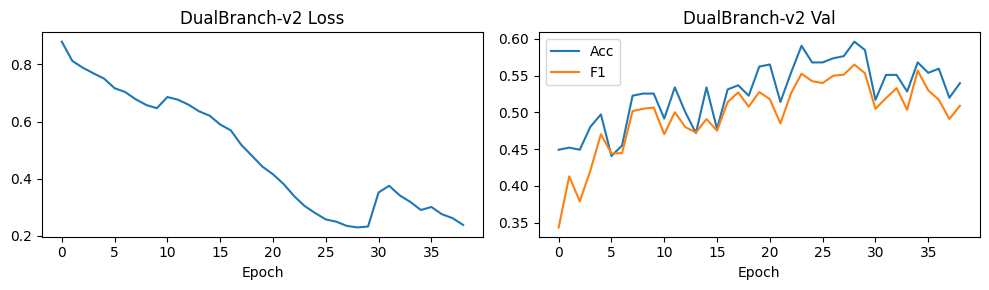


── DualBranch-v2 Test Results ──────────────
              precision    recall  f1-score   support

       angry       0.67      0.65      0.66       141
       happy       0.61      0.59      0.60       100
         sad       0.48      0.42      0.45        38
     neutral       0.36      0.41      0.38        75

    accuracy                           0.56       354
   macro avg       0.53      0.52      0.52       354
weighted avg       0.57      0.56      0.56       354


── IEMOCAP test ──────────────
  Accuracy : 0.5593
  Macro-F1 : 0.5237
  WAR      : 0.5593
  UAR      : 0.5192


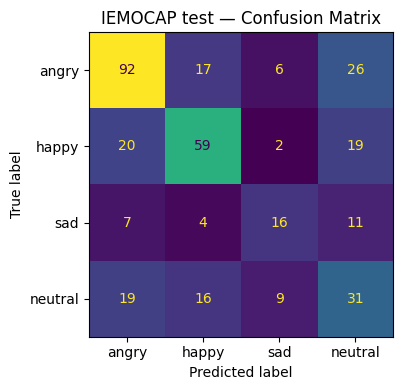

  RTF: 0.00008  (✅ real-time)
✅ DualBranch-v2 saved to Drive.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5. Improved Training loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def soft_cross_entropy_smooth(logits, soft_y, smoothing=0.1):
    n = logits.size(-1)
    soft_y = soft_y * (1 - smoothing) + smoothing / n
    return -(soft_y * F.log_softmax(logits, dim=-1)).sum(dim=-1).mean()


def train_model_v2(model, train_loader, val_loader, model_name='DualBranch-v2',
                   epochs=60, patience=10, lr=1e-4, weight_decay=1e-4):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

    history = {'train_loss':[], 'val_acc':[], 'val_f1':[]}
    best_val_f1, best_state, patience_ctr = -1.0, None, 0

    for epoch in range(1, epochs+1):
        # ── Train ──────────────────────────────────────
        model.train(); epoch_loss = 0.0
        for batch in train_loader:
            x       = batch['x'].to(DEVICE)
            context = batch['context'].to(DEVICE)
            hard_y  = batch['hard_y'].to(DEVICE)
            soft_y  = batch['soft_y'].to(DEVICE)

            logits = model(x, context)
            loss   = (0.4 * soft_cross_entropy_smooth(logits, soft_y) +
                      0.6 * focal_loss_fn(logits, hard_y))

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step(); epoch_loss += loss.item()
        sched.step()

        # ── Validate ────────────────────────────────────
        model.eval(); preds, labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                x       = batch['x'].to(DEVICE)
                context = batch['context'].to(DEVICE)
                preds  += model(x, context).argmax(1).cpu().tolist()
                labels += batch['hard_y'].tolist()

        val_acc = accuracy_score(labels, preds)
        val_f1  = f1_score(labels, preds, average='macro', zero_division=0)
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f'[{model_name}] Ep {epoch:3d} | Loss {avg_loss:.4f} | '
              f'Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f}')

        # Early stopping 监控 Macro-F1
        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            print(f'  ✅ New best F1: {best_val_f1:.4f}')
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'Early stop @ epoch {epoch} (best F1={best_val_f1:.4f})')
                break

    model.load_state_dict(best_state)
    return model, history


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 6. Training+evaluation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('='*55)
print('Training: DualBranchSERv2 (all improvements)')
print('  ✦ Focal Loss')
print('  ✦ Label smoothing')
print('  ✦ Dialogue context (2 prev utterances)')
print('  ✦ Data augmentation (neutral/sad oversampled)')
print('  ✦ Larger Bi-LSTM (hidden=384)')
print('  ✦ Early stopping on Macro-F1')
print('='*55)

dual_v2, hist_v2 = train_model_v2(
    DualBranchSERv2(num_classes=N_CLASSES, context_len=2),
    ctx_train_loader, ctx_val_loader,
    model_name='DualBranch-v2'
)

plot_history(hist_v2, 'DualBranch-v2')

# 评估
from sklearn.metrics import classification_report
dual_v2.eval()
preds, labels = [], []
with torch.no_grad():
    for batch in ctx_test_loader:
        preds  += dual_v2(batch['x'].to(DEVICE),
                          batch['context'].to(DEVICE)).argmax(1).cpu().tolist()
        labels += batch['hard_y'].tolist()

print('\n── DualBranch-v2 Test Results ──────────────')
print(classification_report(labels, preds, target_names=SHARED_LABELS))

results['DualBranch-v2'] = evaluate(dual_v2, ctx_test_loader, 'IEMOCAP test',
                                     use_context=True)
results['DualBranch-v2']['RTF'] = measure_rtf(dual_v2, ctx_test_loader,
                                               use_context=True)

# save model
torch.save(dual_v2.state_dict(), CKPT / 'dual_branch_v2.pth')
with open(CKPT / 'dual_v2_history.pkl', 'wb') as f: pickle.dump(hist_v2, f)
with open(CKPT / 'results.pkl', 'wb') as f: pickle.dump(results, f)
print('✅ DualBranch-v2 saved to Drive.')

## Cell 19 — Results Comparison Table & Chart

In [ ]:
df_r = pd.DataFrame(results).T[['accuracy','macro_f1','WAR','UAR','RTF']].round(4)
df_r.columns = ['Accuracy','Macro-F1','WAR','UAR','RTF']
print('\n' + '='*60 + '\nMODEL COMPARISON — IEMOCAP TEST SET\n' + '='*60)
print(df_r.to_string())

ax = df_r[['Accuracy','Macro-F1','UAR']].plot(kind='bar', figsize=(10,4), rot=30)
ax.set_title('Model Comparison — IEMOCAP Test Set')
ax.set_ylabel('Score'); ax.set_ylim(0,1); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DeepLearningProject/model_comparison.png', dpi=150)
plt.show()
print('Chart saved to Drive.')

## Cell 20 — Save Checkpoints

In [ ]:
CKPT = Path('/content/drive/MyDrive/DeepLearningProject')
torch.save(mlp_model.state_dict(),  CKPT / 'baseline_mfcc_mlp.pth')
torch.save(cnn_model.state_dict(),  CKPT / 'baseline_logmel_cnn.pth')
torch.save(lstm_model.state_dict(), CKPT / 'baseline_cnn_lstm.pth')
# torch.save(dual_model.state_dict(), CKPT / 'dual_branch_ser_best.pth')
print('All checkpoints saved.')